# SGD Model Predictions Visualization

Visualize pixel-wise predictions from the SGD classifier across all years.
Compare predictions (with custom colormap) to ground truth labels with forest mask overlay.

In [379]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import zarr
import pickle
import random
from pathlib import Path

# Set random seed for reproducibility
#random.seed(42)
#np.random.seed(42)

In [380]:
# Load data splits
data_split = np.load('data_split.npz', allow_pickle=True)
test_cube_indices = data_split['test_cube_indices']
test_pixel_indices = data_split['test_pixel_indices']

# Load cube names if available (for name-based lookups)
try:
    test_cube_names = data_split['test_cube_names']
    print(f"Test cubes available: {len(test_cube_names)} (by name)")
    print(f"Test cube names sample: {test_cube_names[:5]}")
except KeyError:
    test_cube_names = None
    print(f"Test cubes available: {len(test_cube_indices)} (numeric indices only)")
    print(f"Test cube indices sample: {test_cube_indices[:5]}")

print(f"Test pixels total: {len(test_pixel_indices)}")

Test cubes available: 297 (numeric indices only)
Test cube indices sample: [1825 1735  678  351 1791]
Test pixels total: 1283992


In [381]:
# Load training data (contains x, y, cube_idx, disturbances, etc.)
training_data = zarr.open('training_data.zarr', mode='r')

print("Training data variables:")
print(training_data.keys())
print(f"\nTraining data dimensions: {training_data['cube_idx'].shape}")
print(f"Example cube indices: {training_data['cube_idx'][:10]}")
print(f"Example x coordinates: {training_data['x'][:10]}")
print(f"Example y coordinates: {training_data['y'][:10]}")

Training data variables:
<generator object Group.keys at 0x0000026D2C92AF60>

Training data dimensions: (8155205,)
Example cube indices: [0 0 0 0 0 0 0 0 0 0]
Example x coordinates: [ 88  55 101 104  33  46  42 106   7   3]
Example y coordinates: [ 13  59  32 118  79  98  90  35  91  83]


In [382]:
# Load full dataset for forest mask
full_dataset = zarr.open('full_dataset_resizedv2.zarr', mode='r')

print("Full dataset variables:")
print(list(full_dataset.keys()))

# Load cube names from full dataset for mapping
full_dataset_cube_names = np.array(full_dataset['cube'][:])
print(f"Full dataset has {len(full_dataset_cube_names)} cubes")
print(f"Sample cube names: {full_dataset_cube_names[:5]}")

def map_training_idx_to_full(training_cube_idx):
    """Map training cube index to full_dataset index using cube names"""
    # Find a pixel with this training cube index
    pixels_with_idx = np.where(training_data['cube_idx'][:] == training_cube_idx)[0]
    if len(pixels_with_idx) == 0:
        raise ValueError(f"No training pixels found with cube_idx={training_cube_idx}")
    
    # Get the cube name
    pixel_idx = pixels_with_idx[0]
    cube_name = training_data['cube_name'][pixel_idx]
    print(f"Training cube_idx {training_cube_idx} → cube_name '{cube_name}'")
    
    # Find this cube in full_dataset
    full_cube_idx = np.where(full_dataset_cube_names == cube_name)[0]
    if len(full_cube_idx) == 0:
        raise ValueError(f"Cube name '{cube_name}' not found in full_dataset")
    
    return full_cube_idx[0]

Full dataset variables:
['S2', 'S2_norm', 'SCL', 'SCL_count', 'SCL_count_norm', 'anyhist_disturbances', 'cloudmask', 'cube', 'dem', 'dem_norm', 'disturbance_agent', 'disturbance_prob', 'disturbances', 'forest_mask', 'forest_mask_static', 'hist_disturbances', 'lccs_class', 'norm', 'original_x', 'original_x_300', 'original_y', 'original_y_300', 'pos', 'position', 's2_band', 'scl_class', 'spatial_ref', 'statistic', 'time', 'topK', 'weather', 'weather_band', 'weather_norm', 'weather_stats', 'weather_stats_norm', 'x', 'x_300', 'y', 'y_300', 'year']
Full dataset has 2216 cubes
Sample cube names: ['mc_-0.04_51.09_1.2_20230627_0' 'mc_-0.06_44.09_1.2_20230627_0'
 'mc_-0.06_51.21_1.2_20230627_0' 'mc_-0.28_45.20_1.2_20230627_0'
 'mc_-0.43_44.22_1.2_20230627_0']


In [383]:
# ==================================================
# OPTION 1: Select a random test cube (uncomment below)
# ==================================================
use_random = False  # Set to False to use specific cube instead

if use_random:
    selected_training_cube_idx = np.random.choice(test_cube_indices)
    print(f"Selected random training cube index: {selected_training_cube_idx}")
else:
    # ==================================================
    # OPTION 2: Specify a particular cube index (edit below)
    # ==================================================
    selected_training_cube_idx = 196  # ← CHANGE THIS to your desired cube index
    
    if selected_training_cube_idx not in test_cube_indices:
        print(f"ERROR: Cube index {selected_training_cube_idx} is not in test set!")
        print(f"Available test cube indices: {sorted(test_cube_indices)[:20]}...")
        raise ValueError(f"Cube {selected_training_cube_idx} not in test set")
    
    print(f"Selected specific training cube index: {selected_training_cube_idx}")

# Get the cube name from training data
pixels_with_idx = np.where(training_data['cube_idx'][:] == selected_training_cube_idx)[0]
selected_cube_name = training_data['cube_name'][pixels_with_idx[0]]
print(f"Selected cube name: '{selected_cube_name}'")

# Map to full_dataset index
selected_full_cube_idx = map_training_idx_to_full(selected_training_cube_idx)
print(f"Full dataset cube index: {selected_full_cube_idx}")

# Find all pixels from this cube in the training data (across all years)
cube_pixels_mask = training_data['cube_idx'][:] == selected_training_cube_idx
cube_pixels_indices = np.where(cube_pixels_mask)[0]

print(f"Total pixels from this cube in training data: {len(cube_pixels_indices)}")

Selected specific training cube index: 196
Selected cube name: 'mc_0.75_42.84_1.1_20230611_0'
Training cube_idx 196 → cube_name 'mc_0.75_42.84_1.1_20230611_0'
Full dataset cube index: 246
Total pixels from this cube in training data: 2478


In [384]:
# Extract spatial information for this cube
x_coords = training_data['x'][cube_pixels_indices]
y_coords = training_data['y'][cube_pixels_indices]

# Check year structure
print(f"Year shape: {training_data['year'].shape}")
print(f"Year sample values: {training_data['year'][:]}")

print(f"X coordinates range: {x_coords.min()} to {x_coords.max()}")
print(f"Y coordinates range: {y_coords.min()} to {y_coords.max()}")

# Get unique coordinates to determine grid size
unique_x = np.unique(x_coords)
unique_y = np.unique(y_coords)
print(f"Unique X values: {len(unique_x)}, Unique Y values: {len(unique_y)}")

Year shape: (7,)
Year sample values: [2016 2017 2018 2019 2020 2021 2022]
X coordinates range: 0 to 127
Y coordinates range: 0 to 127
Unique X values: 128, Unique Y values: 128


In [385]:
# Load forest masks for all years for the selected cube (use full_dataset index)
forest_masks_by_year = full_dataset['forest_mask'][selected_full_cube_idx, :, :, :]
print(f"Forest masks shape (all years): {forest_masks_by_year.shape}")
print(f"Forest mask unique values: {np.unique(forest_masks_by_year)}")
print(f"Loading forest mask for cube: '{selected_cube_name}' (full_dataset[{selected_full_cube_idx}])")

# Check if forest mask is static across years
is_static = np.all(forest_masks_by_year == forest_masks_by_year[0])
print(f"Forest mask is static across years: {is_static}")

# Also load the forest_mask_static if available
try:
    forest_mask_static = full_dataset['forest_mask_static'][selected_full_cube_idx, :, :]
    print(f"Forest mask static shape: {forest_mask_static.shape}")
except:
    forest_mask_static = None
    print("Forest mask static not available")

Forest masks shape (all years): (7, 128, 128)
Forest mask unique values: [0 1]
Loading forest mask for cube: 'mc_0.75_42.84_1.1_20230611_0' (full_dataset[246])
Forest mask is static across years: False
Forest mask static shape: (128, 128)


In [386]:
def create_custom_colormap():
    """
    Create custom colormap for prediction probabilities:
    Continuous spectrum from green (prob=0) to red (prob=1)
    """
    from matplotlib.colors import LinearSegmentedColormap
    
    # Create continuous colormap from green to red
    colors = ['green', 'red']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('green_red', colors, N=n_bins)
    norm = None  # Use default normalization (0 to 1)
    
    return cmap, norm

# Test the colormap
cmap, norm = create_custom_colormap()
print("Custom colormap created successfully")

Custom colormap created successfully


In [387]:
def create_spatial_grids(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grids from scattered pixel coordinates and values.
    Only pixels in the training set will have values; others will be NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)
    
    grid = np.full(grid_shape, np.nan)
    
    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val
    
    return grid

# Determine full grid shape
max_x = int(x_coords.max()) + 1
max_y = int(y_coords.max()) + 1
grid_shape = (max_y, max_x)
print(f"Grid shape will be: {grid_shape}")

Grid shape will be: (128, 128)


In [388]:
# Load training data with features
training_data_features = zarr.open('training_data_with_features.zarr', mode='r')

print("Training data with features variables:")
print(list(training_data_features.keys()))
print(f"Dimensions: {training_data_features['dem'].shape}")

Training data with features variables:
['cube_idx', 'cube_name', 'dem', 'disturbances', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_delta', 'ndwi', 'ndwi_delta', 'pixel', 's2_band', 's2_bands', 'x', 'y', 'year', 'year_disturbance']
Dimensions: (8155205, 7)


In [389]:
def load_year_model(year):
    """Load the model trained for a specific year."""
    model_path = Path(f'models_huber/model_year_{year}_huber.pkl')
    if not model_path.exists():
        print(f"Warning: Model for year {year} not found at {model_path}")
        return None
    
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model

def load_year_scaler(year):
    """Load the scaler fitted for a specific year."""
    scaler_path = Path(f'models_huber/scaler_year_{year}_huber.pkl')
    if not scaler_path.exists():
        print(f"Warning: Scaler for year {year} not found at {scaler_path}")
        return None
    
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    return scaler

# Cache for loaded scalers to avoid redundant disk reads
year_scaler_cache = {}

def get_scaler_for_year(year):
    """Get scaler for a year, using cache to avoid reloading."""
    if year not in year_scaler_cache:
        year_scaler_cache[year] = load_year_scaler(year)
    return year_scaler_cache[year]

# Check which year models and scalers are available
models_dir = Path('models_huber')
available_years = []
for year in [2017, 2018, 2019, 2020, 2021, 2022]:
    model_path = models_dir / f'model_year_{year}_huber.pkl'
    scaler_path = models_dir / f'scaler_year_{year}_huber.pkl'
    if model_path.exists() and scaler_path.exists():
        available_years.append(year)
        print(f"Year {year}: ✓ model and scaler available")
    elif model_path.exists():
        print(f"Year {year}: ✗ model exists but scaler missing")
    elif scaler_path.exists():
        print(f"Year {year}: ✗ scaler exists but model missing")
    else:
        print(f"Year {year}: ✗ neither model nor scaler available")

print(f"\nAvailable year pairs (model + scaler): {available_years}")


Year 2017: ✓ model and scaler available
Year 2018: ✓ model and scaler available
Year 2019: ✓ model and scaler available
Year 2020: ✓ model and scaler available
Year 2021: ✓ model and scaler available
Year 2022: ✓ model and scaler available

Available year pairs (model + scaler): [2017, 2018, 2019, 2020, 2021, 2022]


In [390]:
def extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features):
    """
    Extract feature vectors for a cube at a specific year.
    Returns features array suitable for model prediction.
    NaN values are filled with 0 for prediction.
    """
    # Get S2 bands (8 bands)
    s2_bands = training_data_features['s2_bands'][cube_pixels_indices, year_idx, :].astype(np.float64)
    
    # Get DEM (same for all years, take from year_idx anyway)
    dem = training_data_features['dem'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    
    # Get spectral indices
    ndvi = training_data_features['ndvi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    ndwi = training_data_features['ndwi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    nbr = training_data_features['nbr'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    
    # Get deltas (only available for year_idx >= 1)
    if year_idx >= 1:
        ndvi_delta = training_data_features['ndvi_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        ndwi_delta = training_data_features['ndwi_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        nbr_delta = training_data_features['nbr_delta'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    else:
        # For year 0, deltas are 0
        ndvi_delta = np.zeros((len(cube_pixels_indices), 1))
        ndwi_delta = np.zeros((len(cube_pixels_indices), 1))
        nbr_delta = np.zeros((len(cube_pixels_indices), 1))
    
    # Concatenate all features
    features = np.hstack([s2_bands, dem, ndvi, ndwi, nbr, ndvi_delta, ndwi_delta, nbr_delta])
    
    # For prediction, impute NaN values with 0
    features_for_pred = features.copy()
    features_for_pred[np.isnan(features_for_pred)] = 0.0
    
    # Return both: features_for_pred (for model) and original features (to track NaNs)
    return features_for_pred, features

print("Feature extraction function with NaN tracking defined")

Feature extraction function with NaN tracking defined


In [391]:
# Create a mapping from year values to year indices
year_values = training_data['year'][:]
year_to_idx = {year: idx for idx, year in enumerate(year_values)}

print(f"Year mapping: {year_to_idx}")

# Get ground truth disturbances for all pixels in this cube (all years)
disturbances_all = training_data_features['disturbances'][cube_pixels_indices, :]
print(f"Disturbances shape for cube: {disturbances_all.shape}")

Year mapping: {2016: 0, 2017: 1, 2018: 2, 2019: 3, 2020: 4, 2021: 5, 2022: 6}
Disturbances shape for cube: (2478, 7)


In [392]:
def create_forest_mask_overlay(forest_mask_2d, alpha=0.3):
    """
    Create an RGBA overlay for forest mask.
    Light purple (for forest=1) with alpha transparency.
    """
    overlay = np.zeros((*forest_mask_2d.shape, 4), dtype=np.float32)
    # For forest pixels (value=1), set to light purple with transparency
    forest_pixels = forest_mask_2d == 1
    overlay[forest_pixels, :] = [0.8, 0.5, 0.8, alpha]  # Light purple (RGBA)
    return overlay

print("Forest mask overlay function created")

Forest mask overlay function created


In [393]:
def create_spatial_grid_with_nan(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grid preserving NaN values.
    Pixels not in the training set or with NaN values remain NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)
    
    grid = np.full(grid_shape, np.nan)
    
    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val
    
    return grid

def visualize_year(year, year_idx, model, scaler, cube_pixels_indices, x_coords, y_coords, 
                   disturbances_all, forest_mask_year, grid_shape, cmap, norm):
    """
    Create visualization for a specific year.
    Shows predictions vs ground truth side by side.
    NaNs are displayed as black.
    Uses the forest mask for the specific year.
    
    Args:
        year: Year value (e.g., 2017)
        year_idx: Year index (0-based)
        model: Trained model for the year
        scaler: Fitted scaler for the year
        cube_pixels_indices: Indices of pixels in the cube
        x_coords, y_coords: Spatial coordinates of cube pixels
        disturbances_all: Ground truth disturbances for all pixels/years
        forest_mask_year: Forest mask for this specific year
        grid_shape: Shape of output grid
        cmap: Colormap for visualization
        norm: Normalization for colormap
    """
    # Extract features for this year
    features_for_pred, features_with_nan = extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features)
    
    # Scale features using the year-specific scaler before making predictions
    features_scaled = scaler.transform(features_for_pred)
    
    # Make predictions
    probabilities = model.predict_proba(features_scaled)[:, 1]  # Probability of class 1 (disturbance)
    ground_truth = disturbances_all[:, year_idx]
    
    # Mark pixels with NaN in any feature as NaN in output (for visualization)
    has_nan = np.any(np.isnan(features_with_nan), axis=1)
    probabilities_vis = probabilities.copy().astype(np.float64)
    probabilities_vis[has_nan] = np.nan
    
    # Create spatial grids
    pred_grid = create_spatial_grid_with_nan(x_coords, y_coords, probabilities_vis, grid_shape)
    gt_grid = create_spatial_grid_with_nan(x_coords, y_coords, ground_truth, grid_shape)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Predictions with NaN as black and forest mask overlay
    im1 = ax1.imshow(pred_grid, cmap=cmap, norm=norm, origin='upper')
    # Add black background for NaN values
    nan_mask = np.isnan(pred_grid)
    black_background = np.zeros((*pred_grid.shape, 3))
    ax1.imshow(np.where(nan_mask[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    forest_overlay = create_forest_mask_overlay(forest_mask_year, alpha=0.2)
    ax1.imshow(forest_overlay, origin='upper')
    ax1.set_title(f'Predictions - {year}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X coordinate')
    ax1.set_ylabel('Y coordinate')
    cbar1 = plt.colorbar(im1, ax=ax1, label='Disturbance Probability')
    
    # Plot 2: Ground truth with NaN as black and forest mask overlay
    gt_cmap = ListedColormap(['green', 'red'])
    gt_norm = BoundaryNorm([0, 0.5, 1.0], 2)
    im2 = ax2.imshow(gt_grid, cmap=gt_cmap, norm=gt_norm, origin='upper')
    # Add black background for NaN values
    nan_mask_gt = np.isnan(gt_grid)
    ax2.imshow(np.where(nan_mask_gt[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    ax2.imshow(forest_overlay, origin='upper')
    ax2.set_title(f'Ground Truth - {year}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X coordinate')
    ax2.set_ylabel('Y coordinate')
    cbar2 = plt.colorbar(im2, ax=ax2, label='Disturbance Label', ticks=[0.25, 0.75])
    cbar2.set_ticklabels(['No Disturbance', 'Disturbance'])
    
    plt.tight_layout()
    return fig, probabilities, ground_truth

print("Updated visualization function to use year-specific forest mask and scaler")

Updated visualization function to use year-specific forest mask and scaler


Creating visualizations for cube: mc_0.75_42.84_1.1_20230611_0 (training idx: 196)
Cube contains 2478 pixels from training set
Output directory: c:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations huber


Processing year 2017 (index 1)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2017.png


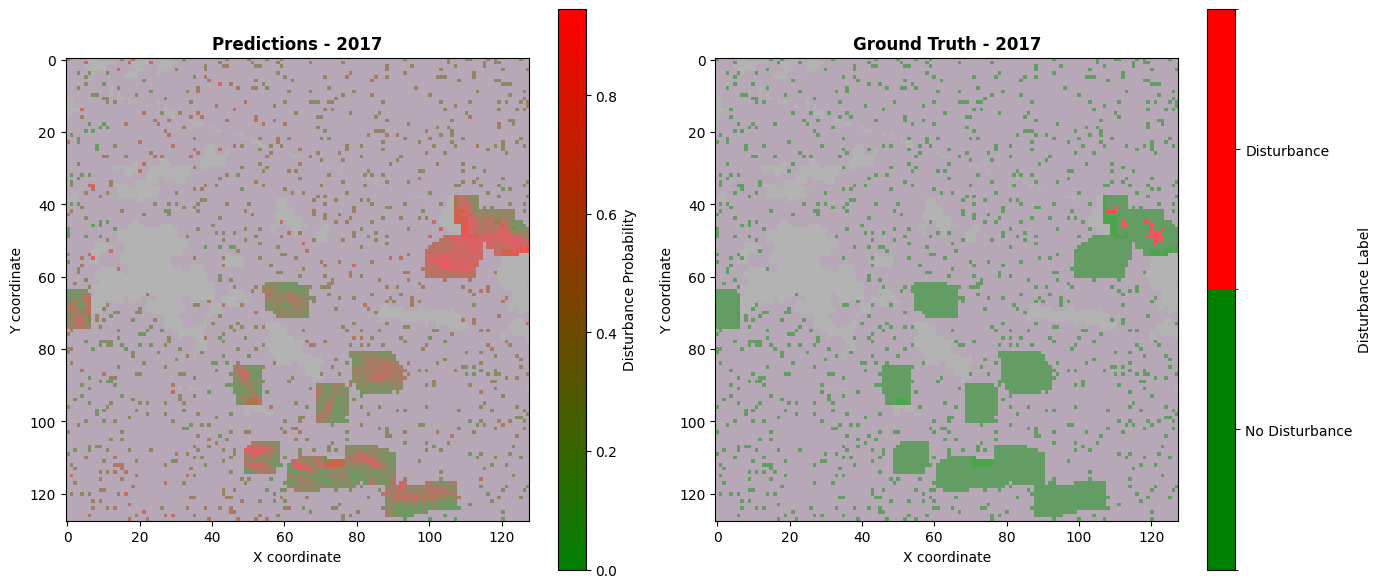


Processing year 2018 (index 2)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2018.png


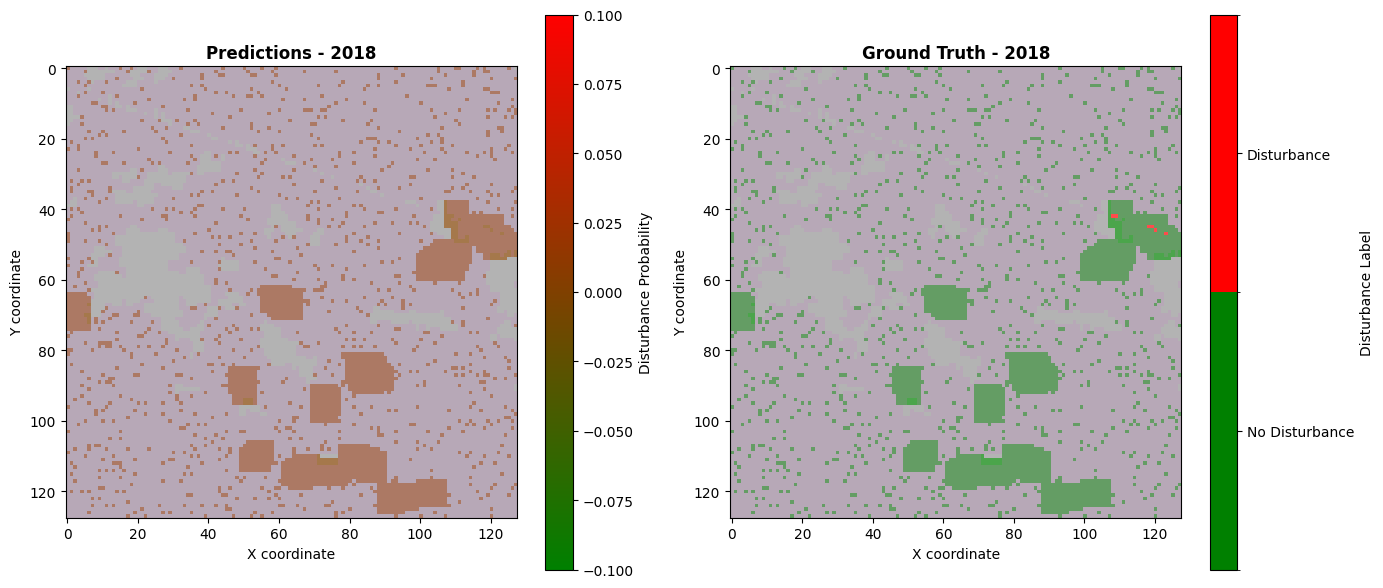


Processing year 2019 (index 3)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2019.png


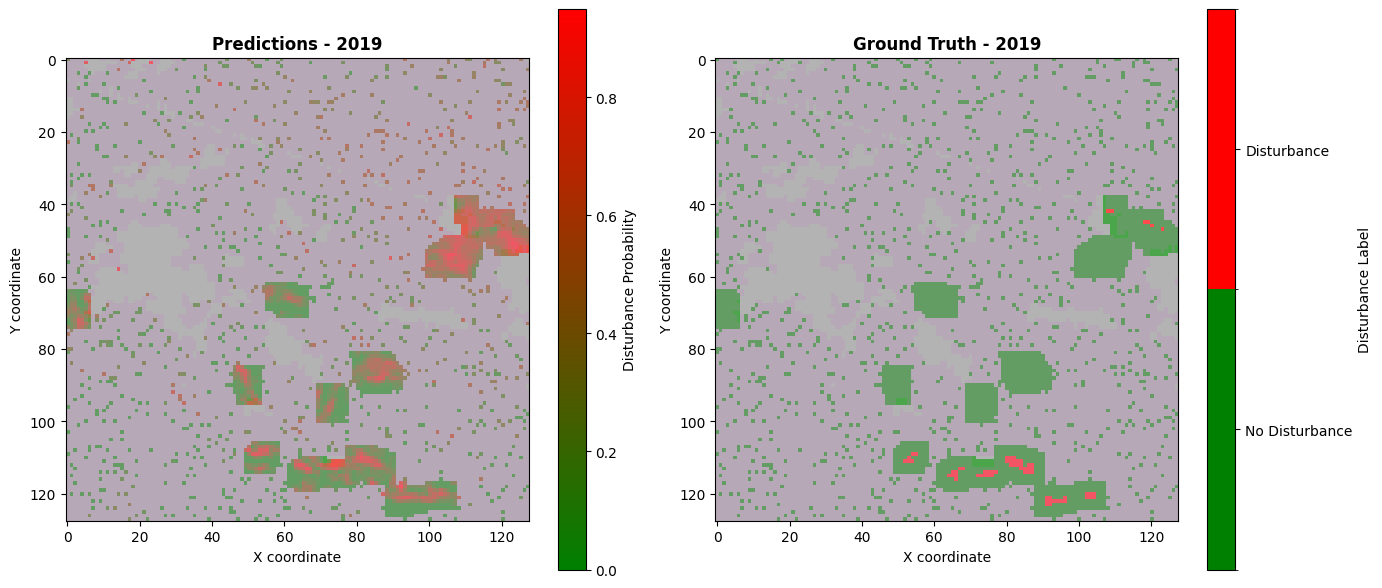


Processing year 2020 (index 4)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2020.png


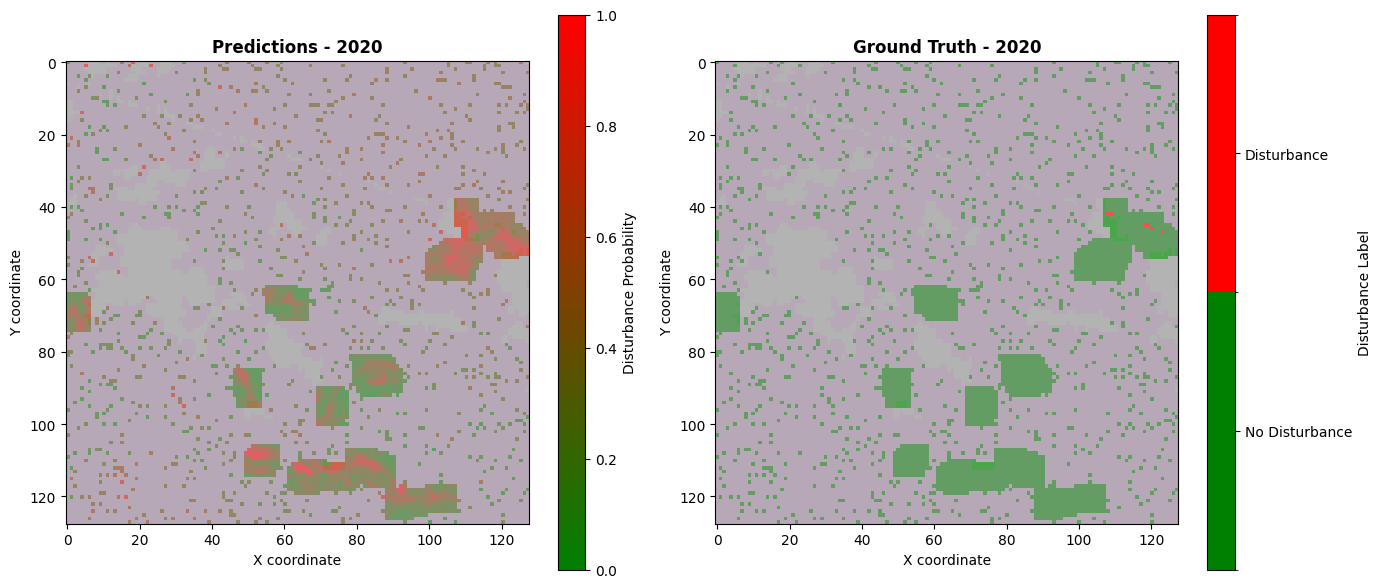


Processing year 2021 (index 5)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2021.png


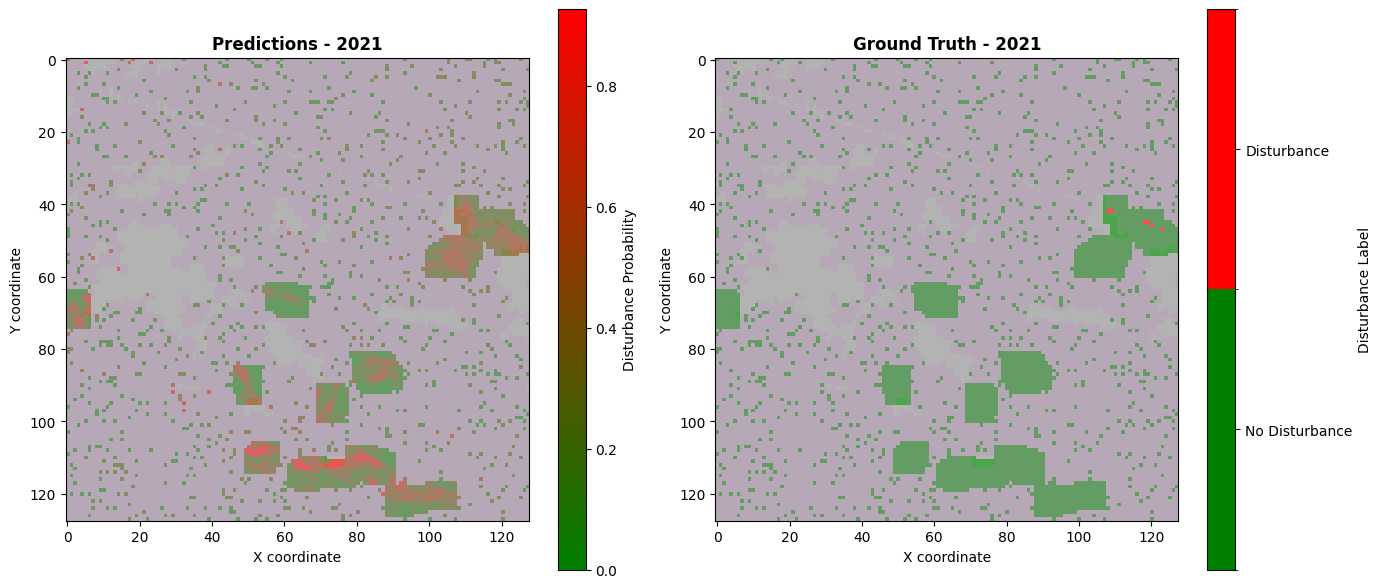


Processing year 2022 (index 6)...
  Saved: prediction visualizations huber\mc_0.75_42.84_1.1_20230611_0_2022.png


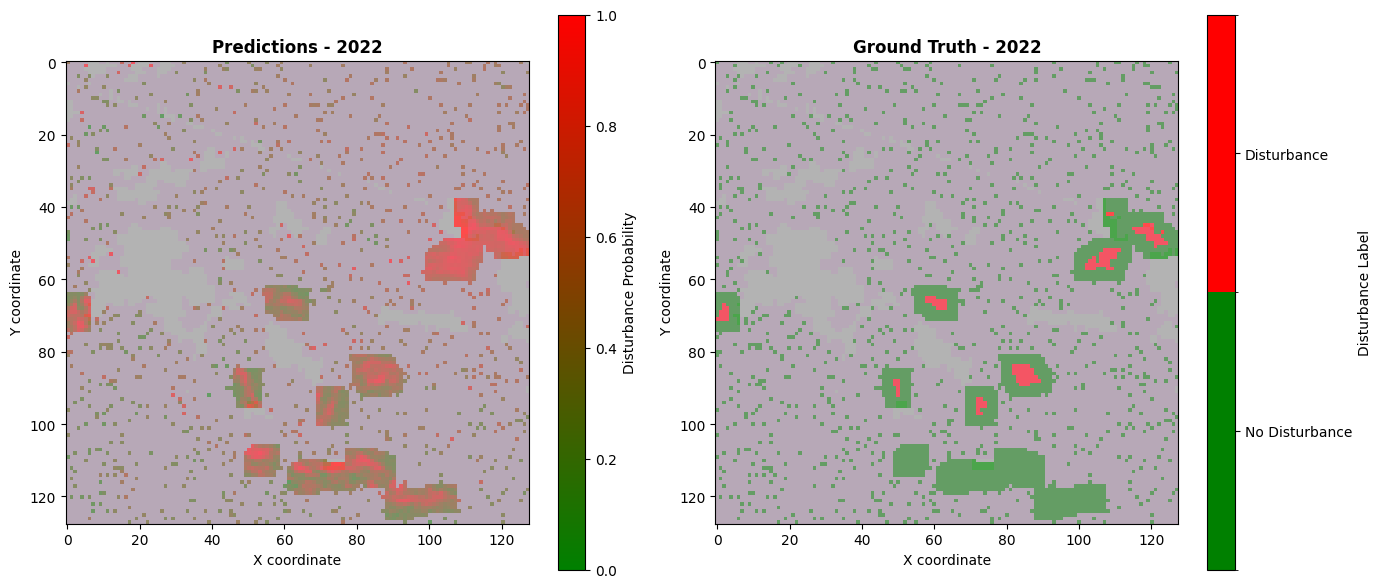


Visualization complete! Created 6 figures
Results saved to: c:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations huber


In [394]:
# Create visualizations for all available years
print(f"Creating visualizations for cube: {selected_cube_name} (training idx: {selected_training_cube_idx})")
print(f"Cube contains {len(cube_pixels_indices)} pixels from training set")
print(f"=" * 60)

# Create output directory for visualizations
output_dir = Path('prediction visualizations huber')
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir.absolute()}\n")

# Create colormap
cmap, norm = create_custom_colormap()

# Store results
all_figures = []
results_by_year = {}

# Years to visualize (2017-2022, indices 1-6)
years_to_visualize = [2017, 2018, 2019, 2020, 2021, 2022]

for year in years_to_visualize:
    year_idx = year_to_idx[year]
    
    # Load the model for this year
    model = load_year_model(year)
    if model is None:
        print(f"Skipping year {year} - model not found")
        continue
    
    # Load the scaler for this year
    year_scaler = get_scaler_for_year(year)
    if year_scaler is None:
        print(f"Skipping year {year} - scaler not found")
        continue
    
    print(f"\nProcessing year {year} (index {year_idx})...")
    
    try:
        # Get forest mask for this specific year
        forest_mask_year = forest_masks_by_year[year_idx, :, :]
        
        # Create visualization using the year-specific scaler
        fig, probabilities, ground_truth = visualize_year(
            year, year_idx, model, year_scaler, cube_pixels_indices, x_coords, y_coords,
            disturbances_all, forest_mask_year, grid_shape, cmap, norm
        )
        
        # Save the figure with cube name in filename
        filename = output_dir / f"{selected_cube_name}_{year}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"  Saved: {filename}")
        
        # Store results
        all_figures.append(fig)
        results_by_year[year] = {
            'probabilities': probabilities,
            'ground_truth': ground_truth,
            'figure': fig
        }
        
        # Display the figure in notebook (don't close it yet)
        plt.show()
        
    except Exception as e:
        print(f"  ERROR processing year {year}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'=' * 60}")
print(f"Visualization complete! Created {len(all_figures)} figures")
print(f"Results saved to: {output_dir.absolute()}")

In [395]:
# Add this after the visualization loop to analyze prediction distributions
print("\n" + "="*60)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*60)

for year, stats in results_by_year.items():
    probs = stats['probabilities']
    print(f"\n{year}:")
    print(f"  Min probability: {probs.min():.4f}")
    print(f"  Max probability: {probs.max():.4f}")
    print(f"  Mean probability: {probs.mean():.4f}")
    print(f"  Std deviation: {probs.std():.4f}")
    print(f"  Median probability: {np.median(probs):.4f}")
    print(f"  % predictions < 0.3: {(probs < 0.3).sum() / len(probs) * 100:.1f}%")
    print(f"  % predictions > 0.7: {(probs > 0.7).sum() / len(probs) * 100:.1f}%")


PREDICTION DISTRIBUTION ANALYSIS

2017:
  Min probability: 0.0000
  Max probability: 0.9452
  Mean probability: 0.3538
  Std deviation: 0.1979
  Median probability: 0.3213
  % predictions < 0.3: 45.7%
  % predictions > 0.7: 7.9%

2018:
  Min probability: 0.0000
  Max probability: 0.0000
  Mean probability: 0.0000
  Std deviation: 0.0000
  Median probability: 0.0000
  % predictions < 0.3: 100.0%
  % predictions > 0.7: 0.0%

2019:
  Min probability: 0.0000
  Max probability: 0.9496
  Mean probability: 0.2621
  Std deviation: 0.2377
  Median probability: 0.2147
  % predictions < 0.3: 58.8%
  % predictions > 0.7: 5.2%

2020:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.3096
  Std deviation: 0.1937
  Median probability: 0.2964
  % predictions < 0.3: 50.6%
  % predictions > 0.7: 4.2%

2021:
  Min probability: 0.0000
  Max probability: 0.9271
  Mean probability: 0.2073
  Std deviation: 0.1746
  Median probability: 0.1733
  % predictions < 0.3: 73.8%
  % predictio

# DIAGNOSTICS

In [396]:
# Diagnostic: Check what features look like
print("\n" + "="*60)
print("FEATURE DIAGNOSTICS")
print("="*60)

features_2017, features_with_nan_2017 = extract_features_for_cube_year(
    cube_pixels_indices, year_to_idx[2017], training_data_features
)

print(f"\n2017 Features shape: {features_2017.shape}")
print(f"% NaN values filled with 0: {np.sum(np.isnan(features_with_nan_2017)) / features_with_nan_2017.size * 100:.1f}%")
print(f"Feature value ranges:")
print(f"  Min: {features_2017.min():.4f}, Max: {features_2017.max():.4f}")
print(f"  Mean: {features_2017.mean():.4f}, Std: {features_2017.std():.4f}")

# Check DEM specifically
dem_idx_0 = training_data_features['dem'][cube_pixels_indices, 0:1]
dem_idx_1 = training_data_features['dem'][cube_pixels_indices, 1:1]
print(f"\nDEM at year_idx=0: {dem_idx_0[:5].ravel()}")
print(f"DEM at year_idx=1: {dem_idx_1[:5].ravel()}")
print(f"Are they identical? {np.allclose(dem_idx_0, dem_idx_1, equal_nan=True)}")


FEATURE DIAGNOSTICS

2017 Features shape: (2478, 14)
% NaN values filled with 0: 0.0%
Feature value ranges:
  Min: -0.8661, Max: 1632.6984
  Mean: 78.0648, Std: 292.8009

DEM at year_idx=0: [1126.73828125  813.96313477 1164.64038086 1609.87548828 1614.57397461]
DEM at year_idx=1: []
Are they identical? True
